In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from skimage import data, io, color

## Trasformazioni geometriche

<a href="https://scikit-image.org/docs/dev/auto_examples/transform/plot_geometric.html#sphx-glr-auto-examples-transform-plot-geometric-py" > Qui la  demo skimage </a>

Nel seguito proviamo invece ad implementare una nostra versione di traslazione e rotazione (intorno all'origine dell'immagine)


In [32]:
# t array 2D
def translate(image, t):
    width,height=image.shape[:2]   
    dst = np.zeros((width, height, 3), dtype=np.uint8)
    # INVERSE MAPPING Loop over the destination, not the source, to ensure that you cover
    # every destination pixel exactly 1 time.
    for u in range(width):
        for v in range(height):
            x = u-t[0]
            y = v-t[1]
            intx, inty = int(x), int(y)
            # bilinear interpolation
            fracx, fracy = x%1, y%1
            if 0 < x < width-1 and 0 < y < height-1:
               # dst[u, v] = image[intx, inty] # qui tronco
               dst[u, v] = fracx*fracy*image[intx, inty]+(1-fracx)*fracy*image[intx+1, inty]+fracx*(1-fracy)*image[intx, inty+1]+(1-fracx)*(1-fracy)*image[intx+1, inty+1]
    return dst

(300, 451, 3)


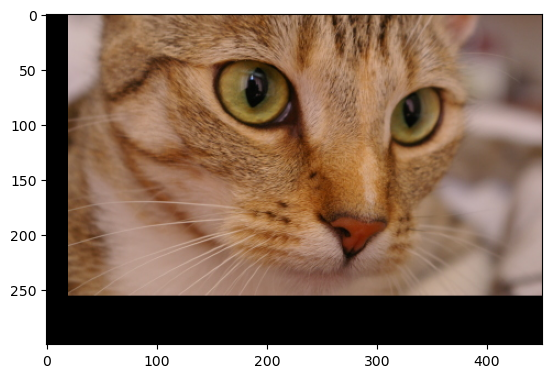

In [33]:
# TEST TRANSLATION
# input a color image
rgb_img = data.cat()  
#rgb_img = plt.imread('images/kitten.jpg')
print(rgb_img.shape)

# translation array
t=[-43,19]
I_t=translate(rgb_img,t)
plt.imshow(I_t) 


In [34]:
def rotation(image, angle):
    width,height=image.shape[:2]   
    dst = np.zeros((width, height, 3), dtype=np.uint8)
    # INVERSE MAPPING Loop over the destination, not the source, to ensure that you cover
    # every destination pixel exactly 1 time.
    for u in range(width):
        for v in range(height):
            x = u*np.cos(-angle)+ v*np.sin(-angle)
            y = -u*np.sin(-angle)+v*np.cos(-angle)
            intx, inty = int(x), int(y)
            # bilinear interpolation
            fracx, fracy = x%1, y%1
            if 0 < x < width-1 and 0 < y < height-1:
                #dst[u, v] = image[intx, inty] # qui tronco
                dst[u, v] = fracx*fracy*image[intx, inty]+(1-fracx)*fracy*image[intx+1, inty]+fracx*(1-fracy)*image[intx, inty+1]+(1-fracx)*(1-fracy)*image[intx+1, inty+1]
    return dst

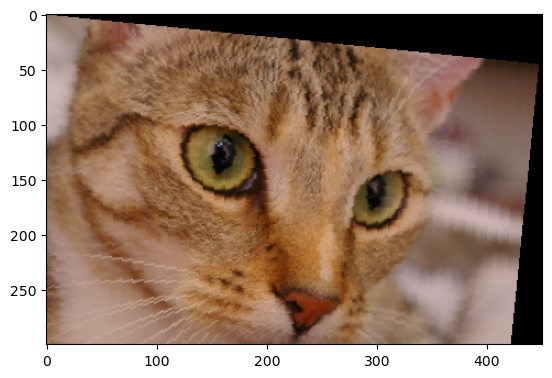

In [38]:
#TEST ROTATION
angle=0.1
rgb_img = data.cat() 
I_rot=rotation(rgb_img,angle)
plt.imshow(I_rot)

Come ruotare intorno al centro dell'immagine?

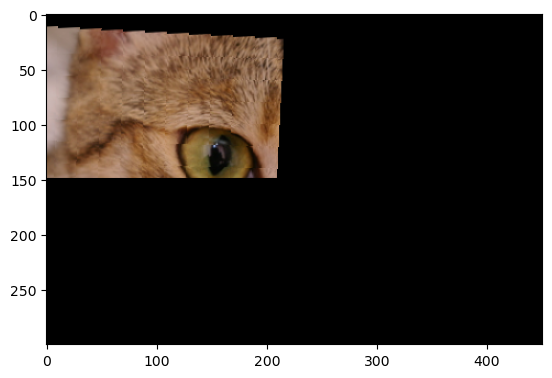

In [42]:
shp=np.shape(rgb_img)
R=shp[0]
C=shp[1]
t=np.array([R//2,C//2])
angle=0.05
I_t=translate(rgb_img,t) #traslo portando l'origine al centro dell'immagine
I_rt=rotation(I_t,angle) #ruoto
I_final=translate(I_rt,-1*t) #traslazione contraria
plt.imshow(I_final,cmap=plt.cm.gray)

Qualcosa non ha funzionato.... cosa?